# QF 627 Programming and Computational Finance
## `Py`Day Week `6` | Confounders, Colliders, & Econometric Methods of Causal Inference Part 1 | `RE`view

> Hi, Team 👋 Thank you for opening the lecture note 🙂

> Tonight, we will first explore the differences between models for `explanation` and models for `prediction`. Understanding this distinction is crucial as it can significantly influence the modeling strategy you use. Without a clear understanding of the question you're asking, you might apply the wrong method, leading to incorrect conclusions from your data. This chapter will demonstrate the consequences of confusing these two types of questions.

> In modeling for explanation purposes (`b-hat` questions), the objective is to estimate the association between a predictor of interest and the outcome. Typically, there are a few key predictors, but numerous potential confounding variables that must be accounted for. The primary goal is to estimate the association while adjusting for these confounders. Sensitivity analyses are often conducted to check if the associations of interest remain stable across different sets of confounding variables.

> In modeling for prediction purposes (`y-hat` questions), the goal is to identify a model that best predicts the outcome. The focus isn't on the predictors per se, as long as they effectively predict the outcome. There is no concern about `confounding` or `predictors of interest`—all predictors are potential contributors to the outcome prediction. Detailed explanations of the predictors or the workings of the model are NOT necessary. The main objective is to develop a model with strong predictive capabilities and to accurately estimate an error rate from the data.

> After establishing a solid understanding of these two primary modeling types, we will dive into the implications of `confounders` and `colliders` in causal inference (modeling for explanatory purposes). You will also learn how to conduct `simulations`—an essential toolkit for real-world problem-solving in analytics across finance and real estate—to create `synthetic data`.

> Next, I'll introduce you to econometric designs and methods of causal inference. As a starting point, I'll discuss two methods: Difference-in-Differences (`DiD`) and Regression Discontinuity (`RDD`).

> Yay~ 🙂

## DEPENDENCIES

In [1]:
# Load libraries.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

import time

import datetime

import warnings
warnings.filterwarnings("ignore")

# Setting baseline seed
np.random.seed(241009)

# Set print options.

np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

%matplotlib inline

# Define our customized timer function

def countdown(Time):
    
    while Time:
        minutes, seconds = divmod(Time, 60)
        timer = "{:02d}:{:02d}".format(minutes, seconds)
        
        print(timer, end = "\r")
        time.sleep(1)
        Time -= 1
        
    print("Let us solve the problem above together :)")

/Users/sroh/miniforge3/envs/rohenv/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 👉 <a id = "top">Learning Pointers</a> 👈 

## [1. Two Worlds of Models](#p1)

> ### <font color = red> To model for explanation or for prediction, that is the question. </font>

## [2. Solving a Business/Policy Question in the Field](#p2)

> ### <font color = red> Air Pollution and Mortality in New York. </font>

## [3. Model for Explanation](#p3)

> ### <font color = red> The B-hat Problem </font>

## [4. Model for Prediction](#p4)

> ### <font color = red> The Y-hat Problem </font>

## [5. Confounders vs. Colliders](#p5)

> ### <font color = red> Simulation with Synthetic Data </font>

## [6. Difference-in-Differences](#p6)

> ### <font color = red> DiD </font>

## [7. Regression Discontinuity](#p7)

> ### <font color = red> RDD </font>

## [8. What We Learned](#p8)

> ### <font color = red> Revisiting Learning Pointers </font>


## <a id = "p1">1. </a> <font color = "green"> Two Worlds of Models </font>  [back to table of contents](#top)

### Qunatitative Modeling Contexts

> `To model for explanation or for prediction, that is the question.` 

> Understanding the difference between answering a model for explanation question versus a model for prediction question is important, as it can greatly impact the modeling strategy used. If you do not clearly understand the type of question you are asking, you may use the wrong modeling approach and arrive at incorrect conclusions from your data. The purpose of this chapter is to demonstrate the consequences of confusing one question for another.

### The key points to remember are:

- For model for ***explanation*** questions, the goal is to estimate the association between a predictor of interest and the outcome. Typically, there are a few predictors of interest (or just one), but many potential confounding variables to consider. The main objective of modeling is to estimate the association while adjusting for any potential confounding factors. Sensitivity analyses are often performed to determine if the associations of interest are robust to different sets of confounding variables.
<br>

- For model for ***prediction*** questions, the goal is to identify a model that best predicts the outcome. There is no prior emphasis on the predictors, so long as they are effective at predicting the outcome. There is no concept of "confounding" or "predictors of interest" as all predictors have the potential to be useful for predicting the outcome. Additionally, the details of "how the model works" or a detailed explanation of the predictors are not necessary. The main objective is to develop a model with good prediction ability and estimate a reasonable error rate from the data.

## <a id = "p2">2.</a>  <font color = "green"> Solving a Business/Policy Question in the Field: Air Pollution and Mortality in New York. </font>  [back to table of contents](#top)

> Our analysis will illustrate how different types of questions and corresponding modeling approaches can result in different conclusions. The data used is air pollution and mortality data for New York City.

In [2]:
# build your customized function to solve the problem

def read_dropbox(url):
    if "?dl=0" in url:
        return url.replace("?dl=0", "?raw=1")
    return url

#### IMPORT

In [3]:
data =\
    pd \
    .read_csv(read_dropbox("https://www.dropbox.com/s/yxqnrlp9z1ify2p/new_york.csv?dl=0")
              )

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20820 entries, 0 to 20819
Columns: 114 entries, city to dow
dtypes: float64(94), int64(16), object(4)
memory usage: 18.1+ MB


In [5]:
data.describe()

,alldeath,accident,copd,cvd,death,Inf,pne_inf,pneu,resp,suicide,...,cotmean,cotmean2,con,comax1,comax2,comax3,comax4,comax5,rmtmpd,rmdptp
count,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,20820.000000,...,20811.000000,20811.000000,20820.000000,20811.000000,20811.000000,20811.000000,20811.000000,20808.000000,20811.000000,20811.000000
mean,64.460423,1.822622,1.723583,29.418252,60.890682,0.005908,2.808405,2.802498,4.531988,0.463737,...,-14.772740,1493.333973,5.715706,5074.873865,4505.809428,4189.808274,3962.361251,3789.158016,55.184582,42.814142
std,29.364291,2.348272,1.597771,21.597851,27.830558,0.077880,2.956371,2.948587,3.933667,0.839935,...,396.653766,753.670578,1.024937,3405.782399,2909.388336,2642.879405,2451.004242,2304.687666,16.408586,17.443515
min,10.000000,0.000000,0.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-2013.449611,245.833333,0.000000,400.000000,200.000000,0.000000,0.000000,0.000000,8.750000,-4.402778
25%,40.000000,0.000000,1.000000,13.000000,37.000000,0.000000,1.000000,1.000000,2.000000,0.000000,...,-230.343346,912.651515,5.000000,2500.000000,2200.000000,2100.000000,2000.000000,2000.000000,41.833333,29.104167
50%,62.000000,1.000000,1.000000,18.000000,54.000000,0.000000,2.000000,2.000000,3.000000,0.000000,...,-57.843446,1335.416667,6.000000,4300.000000,3900.000000,3600.000000,3500.000000,3300.000000,55.222222,42.979167
75%,87.000000,3.000000,3.000000,51.000000,85.000000,0.000000,4.000000,4.000000,7.000000,1.000000,...,144.606851,1882.291667,6.000000,6800.000000,6100.000000,5600.000000,5300.000000,5100.000000,70.333333,58.166667
max,1304.000000,168.000000,13.000000,127.000000,182.000000,2.000000,23.000000,23.000000,27.000000,6.000000,...,3024.501660,5227.717391,8.000000,37400.000000,31500.000000,24800.000000,24800.000000,20400.000000,90.666667,74.770833


In [6]:
data.columns

Index(['city', 'alldeath', 'accident', 'copd', 'cvd', 'death', 'Inf',
       'pne_inf', 'pneu', 'resp',
       ...
       'cotmean2', 'con', 'comax1', 'comax2', 'comax3', 'comax4', 'comax5',
       'rmtmpd', 'rmdptp', 'dow'],
      dtype='object', length=114)

In [7]:
data.shape

(20820, 114)

In [8]:
data.head(3)

,city,alldeath,accident,copd,cvd,death,Inf,pne_inf,pneu,resp,...,cotmean2,con,comax1,comax2,comax3,comax4,comax5,rmtmpd,rmdptp,dow
0,ny,93,10,3,22,73,0,3,3,6,...,2088.352273,6,8100.0,6800.0,6000.0,5200.0,5100.0,NaN,NaN,Thursday
1,ny,77,4,4,20,68,0,1,1,5,...,2049.031385,6,9500.0,9000.0,8800.0,8400.0,8000.0,NaN,NaN,Friday
2,ny,64,5,0,17,56,0,3,3,3,...,1875.815217,6,8400.0,7700.0,6700.0,6200.0,6000.0,NaN,NaN,Saturday


#### WRANGLE

In [9]:
subset_DF =\
data[["date"]].tail()

In [10]:
data[["death"]]

,death
0,73
1,68
2,56
3,55
4,60
...,...
20815,92
20816,79
20817,107
20818,98


In [11]:
# import this

In [12]:
subset_DF =\
(
 data
 [["date", "death"]]
 .loc[data["date"] >= "2001-01-01"]
 .groupby("date")
 .sum()
 .reset_index()
)

In [13]:
subset_DF

,date,death
0,2001-01-01,186
1,2001-01-02,225
2,2001-01-03,202
3,2001-01-04,186
4,2001-01-05,226
...,...,...
1821,2005-12-27,162
1822,2005-12-28,152
1823,2005-12-29,176
1824,2005-12-30,163


In [14]:
(data
 .columns
 .to_frame()
)

,0
city,city
alldeath,alldeath
accident,accident
copd,copd
cvd,cvd
...,...
comax4,comax4
comax5,comax5
rmtmpd,rmtmpd
rmdptp,rmdptp


In [15]:
exposure =\
(    data 
     .drop(["death"],
           axis = 1)
     .loc[(data["agecat"] == "under65") & (data["date"] >= "2001-01-01")                 
         ]
)

In [16]:
exposure

,city,alldeath,accident,copd,cvd,Inf,pne_inf,pneu,resp,suicide,...,cotmean2,con,comax1,comax2,comax3,comax4,comax5,rmtmpd,rmdptp,dow
5114,ny,67,7,2,13,0,0,0,2,2,...,730.000000,7,1800.0,1700.0,1600.0,1600.0,1600.0,26.888889,17.444444,Monday
5115,ny,64,5,1,13,0,1,1,2,0,...,934.762846,7,2900.0,2500.0,2300.0,2200.0,2200.0,28.111111,17.955556,Tuesday
5116,ny,55,1,1,12,0,2,2,3,1,...,1207.500000,7,2600.0,2400.0,2400.0,2300.0,2300.0,26.333333,13.655556,Wednesday
5117,ny,55,4,4,10,0,0,0,4,2,...,1249.206192,7,2600.0,2500.0,2500.0,2300.0,2200.0,25.444444,13.355556,Thursday
5118,ny,64,2,2,21,0,0,0,2,0,...,1350.000000,6,3000.0,2900.0,2500.0,2400.0,2300.0,25.888889,15.077778,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6935,ny,47,2,0,13,0,1,1,1,2,...,494.507576,4,1400.0,900.0,900.0,900.0,800.0,46.000000,36.444444,Tuesday
6936,ny,48,2,0,11,0,0,0,0,0,...,704.464286,4,1600.0,1500.0,1300.0,1300.0,1300.0,43.555556,35.522222,Wednesday
6937,ny,45,2,1,10,0,0,0,1,2,...,783.333333,4,2200.0,2200.0,1800.0,1700.0,1600.0,42.333333,33.644444,Thursday
6938,ny,47,4,2,16,0,1,1,3,1,...,533.333333,4,1100.0,1100.0,1000.0,800.0,800.0,43.111111,35.566667,Friday


In [17]:
data_for_analysis =\
(    pd
     .merge(subset_DF, exposure,
            on = "date")
)

In [18]:
print(subset_DF.shape);print(exposure.shape);print(data_for_analysis.shape)

(1826, 2)
(1826, 113)
(1826, 114)


In [19]:
data_for_analysis.dtypes

date         object
death         int64
city         object
alldeath      int64
accident      int64
             ...   
comax4      float64
comax5      float64
rmtmpd      float64
rmdptp      float64
dow          object
Length: 114, dtype: object

In [20]:
data_for_analysis \
    .date

0       2001-01-01
1       2001-01-02
2       2001-01-03
3       2001-01-04
4       2001-01-05
           ...    
1821    2005-12-27
1822    2005-12-28
1823    2005-12-29
1824    2005-12-30
1825    2005-12-31
Name: date, Length: 1826, dtype: object

In [21]:
data_for_analysis["date"] =\
(
    pd
    .to_datetime(data_for_analysis["date"]
                )
)

data_for_analysis \
    .dtypes

date        datetime64[ns]
death                int64
city                object
alldeath             int64
accident             int64
                 ...      
comax4             float64
comax5             float64
rmtmpd             float64
rmdptp             float64
dow                 object
Length: 114, dtype: object

In [22]:
data_for_analysis["season"] =\
(    data_for_analysis
     ["date"]
     .dt
     .quarter
)

(
    data_for_analysis 
    .season
    .unique()
)

array([1, 2, 3, 4], dtype=int32)

In [23]:
data_for_analysis["season"] =\
(
    data_for_analysis
    ["season"]
    .astype("category")
)

data_for_analysis \
    .season

0       1
1       1
2       1
3       1
4       1
       ..
1821    4
1822    4
1823    4
1824    4
1825    4
Name: season, Length: 1826, dtype: category
Categories (4, int32): [1, 2, 3, 4]

In [24]:
data_for_analysis["dow"] =\
(
    data_for_analysis
    ["date"] 
    .dt
    .weekday
)

In [25]:
data_for_analysis \
    .dow \
    .unique()

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

#### VISUALIZE

> Let's visualize the daily mortality data from all causes for the years 2001 to 2005.

In [26]:
# data_for_analysis \
#     .columns \
#     .to_frame()

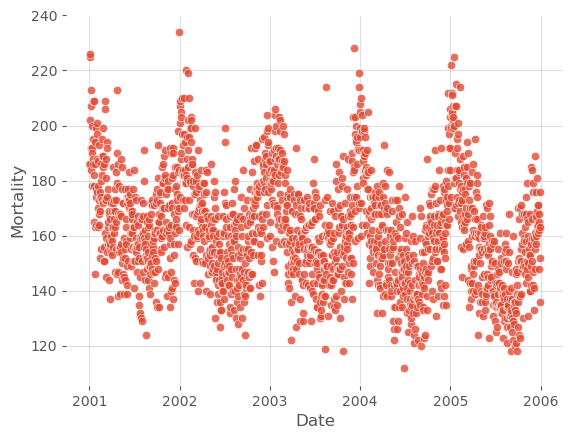

In [27]:
sns \
    .scatterplot(x = "date",
                 y = "death",
                 data = data_for_analysis,
                 alpha = 0.80)

plt \
    .xlabel("Date")

plt \
    .ylabel("Mortality")

plt \
    .show()

> Next, let's visualize a plot of the 24-hour average levels of particulate matter with aerodynamic diameter less than or equal to 10 microns (PM10).

In [28]:
data_for_analysis =\
    data_for_analysis \
    .rename(columns = {"no2tmean": "no2",
                       "pm10tmean": "pm10"}
           )

In [29]:
pm10_array =\
(
    np
    .array(data_for_analysis["pm10"]
           .values)
)

In [30]:
# type(pm10_array)

In [31]:
# data_for_analysis["date"].values

In [32]:
date_array =\
(
    np
    .array(data_for_analysis["date"]
           .values)
)

In [33]:
# date_array

In [34]:
data_for_analysis[["pm10"]]

,pm10
0,-11.303571
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1821,NaN
1822,NaN
1823,NaN
1824,NaN


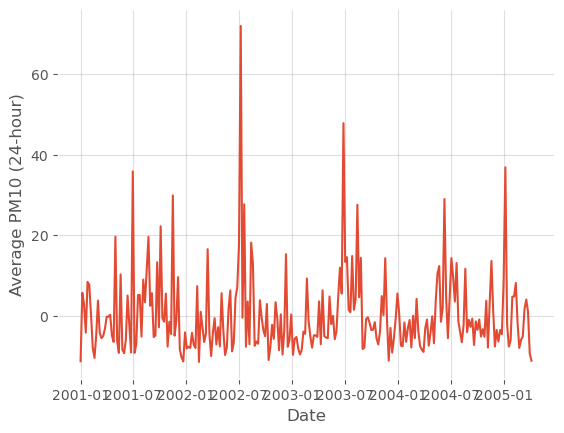

In [35]:
sns \
    .lineplot(x = "date",
              y = "pm10",
              data = data_for_analysis)

plt \
    .ylabel("Average PM10 (24-hour)")

plt \
    .xlabel("Date")

plt \
    .show()

> Note that there are fewer points on the PM10 plot compared to the mortality data plot. This is because PM10 is not measured every day. Additionally, note that there are negative values in the PM10 plot - this is due to the PM10 data being mean-subtracted. In general, negative values of PM10 are not possible.

## <a id = "p3">3.</a>  <font color = "green"> Model for Explanation </font>  [back to table of contents](#top)

> The first step we will take is to determine if there is a correlation between the daily 24-hour average PM10 levels and daily mortality. This is an inference question, and we aim to estimate the association. Additionally, we must consider potential confounding variables while addressing this question.

> We will start by analyzing the bivariate association between PM10 and mortality, using a scatterplot of the two variables. The plot does not show a significant relationship, and the results from a linear regression model of the log of daily mortality and PM10 support this observation.

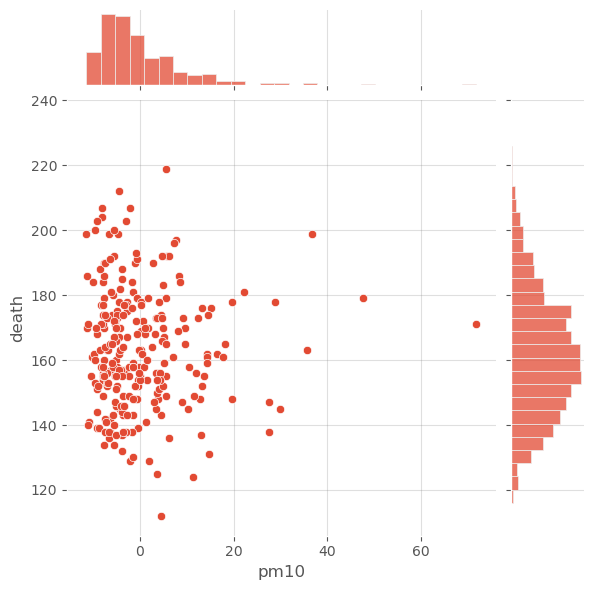

In [36]:
sns \
    .jointplot(x = "pm10",
               y = "death",
               data = data_for_analysis)

plt.show()

In [37]:
import statsmodels.formula.api as smf # smf ==> library in python for model for explanation purposes

In [38]:
regression_0 =\
(
    smf
    .ols("np.log(death) ~ pm10",
         data = data_for_analysis)
    .fit()
)

In [39]:
(regression_0
    .summary()
    .tables[1] # 2nd element of your summary table --> variable-level information
)

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.0888,0.007,733.751,0.000,5.075,5.103
pm10,4.033e-05,0.001,0.058,0.954,-0.001,0.001


> In the table of coefficients, the PM10 coefficient is small and has a large standard error, implying that the estimate of the association is zero. However, both PM10 and daily mortality are influenced by season. Mortality is typically higher in winter and lower in summer, while PM10 shows the opposite pattern, being higher in summer and lower in winter. As season affects both PM10 and mortality, it can be considered a confounder and must be adjusted for in the model.

In [40]:
regression_1 =\
(
    smf
    .ols("np.log(death) ~ pm10 + season",
         data = data_for_analysis)
    .fit()
)    

In [41]:
regression_1 \
    .summary() \
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.1665,0.011,458.715,0.000,5.144,5.189
season[T.2],-0.1093,0.017,-6.547,0.000,-0.142,-0.076
season[T.3],-0.1555,0.017,-9.162,0.000,-0.189,-0.122
season[T.4],-0.0603,0.017,-3.608,0.000,-0.093,-0.027
pm10,0.0015,0.001,2.435,0.016,0.000,0.003


> In the second model, we include PM10 and season as a categorical variable with four levels. The PM10 coefficient is now larger, and the t-value suggests a strong association. This result is due to Simpson's Paradox, where the overall relationship between PM10 and mortality is null, but after considering the seasonal variation in both variables, the association becomes positive.

In [42]:
data_for_analysis[["date"]]

,date
0,2001-01-01
1,2001-01-02
2,2001-01-03
3,2001-01-04
4,2001-01-05
...,...
1821,2005-12-27
1822,2005-12-28
1823,2005-12-29
1824,2005-12-30


In [43]:
# This is what you do when dealing with date in regression

data_for_analysis["date"] =\
(    data_for_analysis
     ["date"]
     .astype(int)
     /
     10
     **
     9
)

In [44]:
# data_for_analysis.date

In [45]:
regression_2 =\
(
    smf
    .ols("np.log(death) ~ pm10 + season + date + tmpd + dptp",
         data = data_for_analysis) 
    .fit()
)

regression_2 \
    .summary() \
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.6207,0.165,34.124,0.000,5.296,5.945
season[T.2],-0.0581,0.023,-2.525,0.012,-0.103,-0.013
season[T.3],-0.0766,0.029,-2.636,0.009,-0.134,-0.019
season[T.4],-0.0315,0.018,-1.721,0.086,-0.068,0.005
pm10,0.0024,0.001,3.600,0.000,0.001,0.004
date,-3.454e-10,1.52e-10,-2.269,0.024,-6.45e-10,-4.56e-11
tmpd,-0.0030,0.001,-2.297,0.022,-0.005,-0.000
dptp,0.0007,0.001,0.660,0.510,-0.001,0.003


> Temperature (`tmpd`) and dew point temperature (`dptp`) are additional weather variables that may impact both PM10 formation and mortality. Thus, we include these variables, along with the date, in the third model. The PM10 coefficient increases again, indicating a continued association between PM10 and mortality.

In [46]:
regression_3 =\
(
    smf 
    .ols("np.log(death) ~ pm10 + season + date + tmpd + dptp + no2",
         data = data_for_analysis)
    .fit()
)

regression_3 \
    .summary() \
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.6138,0.164,34.147,0.000,5.290,5.938
season[T.2],-0.0514,0.023,-2.200,0.029,-0.097,-0.005
season[T.3],-0.0657,0.030,-2.197,0.029,-0.125,-0.007
season[T.4],-0.0275,0.018,-1.487,0.138,-0.064,0.009
pm10,0.0017,0.001,2.221,0.027,0.000,0.003
date,-3.442e-10,1.52e-10,-2.266,0.024,-6.43e-10,-4.5e-11
tmpd,-0.0030,0.001,-2.309,0.022,-0.005,-0.000
dptp,0.0007,0.001,0.681,0.497,-0.001,0.003
no2,0.0013,0.001,1.468,0.143,-0.000,0.003


In [47]:
(regression_3 
    .params # returns b (unstandardized regression coeffecients)
    ["pm10"] # returns regression coefficient for pm10
    .round(3)
)

0.002

In [48]:
(
    regression_3 # regression model
    .conf_int() # . access confidence intervals
    .loc["pm10"] # pm10
)

0    0.000197
1    0.003287
Name: pm10, dtype: float64

> Another class of confounding variables is other pollutants, such as NO2, which shares some sources with PM10 and has been linked to mortality. The final model includes NO2, and the results show that the NO2 coefficient is similar in magnitude to the PM10 coefficient, but with a smaller t-value. The PM10 coefficient remains statistically significant, although its magnitude decreases.

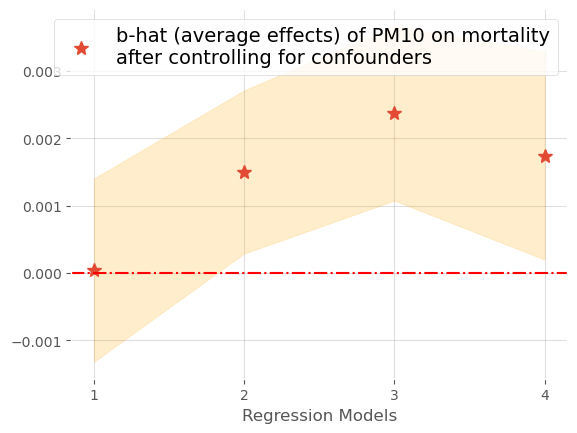

In [49]:
# Let's build a plot to compare the above four regression models

# point estimation of the effects within our available data

effects_of_pm10_within_data =\
(    
    np # effects that you could find within your data ==> statistic
    .array([regression_0.params["pm10"],
            regression_1.params["pm10"],
            regression_2.params["pm10"],
            regression_3.params["pm10"]
           ]
          )

)

# take into account confidence intervals (uncertainty) in estimation above

effects_of_pm10_out_of_data =\
(
    np # the potential range of effects that you could find out-of-data (i.e., population) ==> parameters
    .array([regression_0.conf_int().loc["pm10"],
            regression_1.conf_int().loc["pm10"],
            regression_2.conf_int().loc["pm10"],
            regression_3.conf_int().loc["pm10"]
           ]
          )
)

# four regression models

regression_models =\
    np \
    .arange(1, 5)

# Let's visualize

plt \
    .plot(regression_models,
          effects_of_pm10_within_data,
          "*",
          markersize = 10,
          label = "b-hat (average effects) of PM10 on mortality\nafter controlling for confounders"
          )

plt \
    .fill_between(regression_models,
                  effects_of_pm10_out_of_data[ : , 0],
                  effects_of_pm10_out_of_data[ : , 1],
                  color = "orange",
                  alpha = 0.20)

# setting a marker for NULL effects

plt \
    .axhline(0,
             color = "red",
             linestyle = "-.")

# ticks for each model

plt \
    .xticks(regression_models,
            regression_models)

# add labels for your information

plt \
    .xlabel("Regression Models")

plt.legend()

plt.show()

> A plot of the PM10 coefficient from all four models demonstrates a positive association between PM10 and mortality in Models 2-4, with a small effect size. It is essential to consider the impact of the small effect size, as everyone in New York City breathes and even a small effect can have a significant impact. The appropriate course of action will depend on the ultimate goal and is beyond the scope of this discussion.

## <a id = "p4">4.</a>  <font color = "green"> Model for Prediction </font>  [back to table of contents](#top)

> An alternative strategy we could have adopted is asking, "What best predicts mortality in New York City?" Since this is a prediction question, we can use available data to construct a model. In this case, we'll utilize the random forests modeling technique, a machine learning method that is effective when there are many predictors. One of the outputs we can obtain from the random forest method is a measure of variable importance, which roughly indicates how crucial a particular variable is in enhancing the prediction accuracy of the model.

> The following is a variable importance plot generated after fitting a random forest model. Larger values on the x-axis represent higher importance.

In [50]:
data_without_missing_values =\
    data_for_analysis \
    .dropna() # list-wise deletion

In [51]:
# data_for_analysis.shape

In [52]:
# data_without_missing_values.shape

In [53]:
# Machine Learning for Prediction

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [55]:
Xs =\
    data_without_missing_values[["date",
                                 "season",
                                 "no2",
                                 "dptp",
                                 "o3tmean",
                                 "pm10",
                                 "tmpd"]
                               ]

Y = data_without_missing_values["death"]

In [56]:
# Step 1: Data Split

X_train, X_test, Y_train, Y_test =\
    train_test_split(Xs, Y,
                     test_size = 0.20,
                     random_state = 241009)

In [57]:
# Step 3: Model Specification (with Random Forest)

rf =\
    RandomForestRegressor(n_estimators = 100,
                          random_state = 241009)

rf \
    .fit(X_train, Y_train)

RandomForestRegressor(random_state=241009)

In [58]:
Y_hat =\
    rf \
    .predict(X_test)
                                                            # Actual Y vs. Predicted Y 
print("Model Performance based on MSE: %.1f" % mean_squared_error(Y_test, Y_hat)
     )

Model Performance based on MSE: 170.7


### Feature Importance

In [59]:
%whos

Variable                      Type                        Data/Info
-------------------------------------------------------------------
RandomForestRegressor         ABCMeta                     <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X_test                        DataFrame                                 date season<...>0000  \n846   61.000000  
X_train                       DataFrame                                 date season<...>n\n[120 rows x 7 columns]
Xs                            DataFrame                                 date season<...>n\n[151 rows x 7 columns]
Y                             Series                      522     139\n528     136\<...>Length: 151, dtype: int64
Y_hat                         ndarray                     31: 31 elems, type `float64`, 248 bytes
Y_test                        Series                      912     176\n1350    148\<...>Name: death, dtype: int64
Y_train                       Series                      696     153\n528     136

In [60]:
# How to access feature importance in algorithm

rf\
    .feature_importances_

array([0.11 , 0.022, 0.126, 0.205, 0.088, 0.134, 0.316])

Text(0.5, 0, 'Feature Importance')

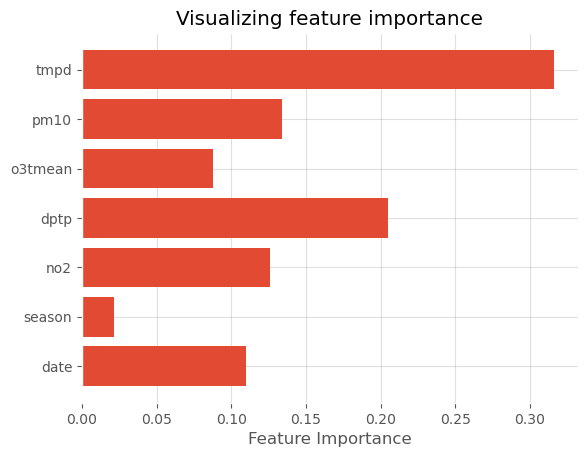

In [61]:
plt\
    .barh(Xs.columns, # print names of input features
          rf.feature_importances_ # print feature importances
         ) 

plt.title("Visualizing feature importance")
plt.xlabel("Feature Importance")

> As seen in the plot, the variable pm10 has a low importance, as it doesn't contribute much to predicting mortality. This aligns with our observation from the previous section that the effect size was small, meaning it didn't explain much variability in mortality. Predictors like temperature and dew point temperature are more helpful in predicting daily mortality, with even NO2 being a better predictor than PM10.

> However, just because PM10 isn't a strong predictor of mortality, it doesn't imply that it has no association with mortality. Given the limitations that come with developing a prediction model, PM10 is not a priority among the predictors we would consider including - it's not feasible to include every predictor.

> In any business analytics task, it's crucial to determine beforehand whether you're seeking a model for explanation or prediction. This decision can shape the entire modeling strategy. In this example, if we had taken a prediction approach, we might have wrongly assumed that PM10 was not related to mortality. However, the inferential approach revealed a statistically significant association with mortality. Properly framing the question and applying the appropriate modeling approach can significantly impact the conclusions drawn from the data.

## <a id = "p5">5. </a> <font color = "green"> Confounders vs. Colliders </font>  [back to table of contents](#top)

### Analytics Contexts

> One of the very first things you might hear in field practice is the concept of controlling variables. Controlling for variables is of crucial importance during the modeling process for explanation (b-hat problem solving). Before diving into learning causal inference with econometric methods and techniques, it is essential to understand what it means to control variables, why it is important, and under which circumstances you should not control variables.

### Problem of Omitted Variable

> When a variable that affects your dependent variable (y) is missing from the model, and at the same time it is correlated with your independent variable (x), you will face omitted variable bias. We call that variable z.

> The problem of omitted variable is in play when you consider the causal relationship between x and y variables. It is referred to as `endogenous.`

In [62]:
# Team, let's build our synthetic world

np\
    .random\
    .seed(241009)

N = 4000

x =\
(
    np
    .random
    .normal(size = N)
)

# Here, let's set TRUE Average Treatment Effects (ATE) of X at 0.40

y = 0.40 * x + np.random.normal(size = N)
               # homoscedasticity

In [63]:
data =\
{"x": x,
 "y": y}

In [64]:
data

{'x': array([ 0.266, -0.252, -1.337, ...,  0.066,  0.227,  0.135]),
 'y': array([ 0.151, -2.394, -0.669, ..., -1.064,  0.1  , -0.023])}

In [65]:
correct_model =\
(
    smf
    .ols("y ~ x",
         data = data)
    .fit()
)

correct_model\
    .summary()\
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0055,0.016,-0.347,0.728,-0.036,0.025
x,0.4038,0.016,25.631,0.000,0.373,0.435


### A Case for Confounders

> Let's first look at a case where your confounding variable can bias regression results if you fail to include it in the regression model.

> The model below will engender the problem of omitted variable bias.

In [66]:
%whos

Variable                      Type                        Data/Info
-------------------------------------------------------------------
N                             int                         4000
RandomForestRegressor         ABCMeta                     <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X_test                        DataFrame                                 date season<...>0000  \n846   61.000000  
X_train                       DataFrame                                 date season<...>n\n[120 rows x 7 columns]
Xs                            DataFrame                                 date season<...>n\n[151 rows x 7 columns]
Y                             Series                      522     139\n528     136\<...>Length: 151, dtype: int64
Y_hat                         ndarray                     31: 31 elems, type `float64`, 248 bytes
Y_test                        Series                      912     176\n1350    148\<...>Name: death, dtype: int64
Y_train            

In [67]:
np.random.seed(241009)

N = 2000

prev_purchase = np.random.normal(size = N)

voucher = 0.50 * prev_purchase + np.random.normal(size = N)

purchase = 0.40 * voucher + 0.30 * prev_purchase + np.random.normal(size = N)

In [68]:
data =\
{"CONFOUNDER_prev_purchase": prev_purchase,
 "X_voucher": voucher,
 "Y_purchase": purchase}

data

{'CONFOUNDER_prev_purchase': array([ 0.266, -0.252, -1.337, ...,  1.241,  1.115,  0.625]),
 'X_voucher': array([-0.317, -1.385, -1.576, ...,  0.687,  0.785,  0.447]),
 'Y_purchase': array([-2.807e-03, -2.923e+00, -1.165e+00, ..., -5.316e-01, -2.121e-01,
         1.197e+00])}

In [69]:
pd.DataFrame(data)

,CONFOUNDER_prev_purchase,X_voucher,Y_purchase
0,0.265789,-0.317152,-0.002807
1,-0.252159,-1.385335,-2.923014
2,-1.336906,-1.575936,-1.165489
3,-0.906898,2.578468,1.820609
4,-0.106715,0.994603,-0.310051
...,...,...,...
1995,-0.474995,-2.071285,-0.642901
1996,0.297553,-0.711842,0.072411
1997,1.241131,0.686874,-0.531595
1998,1.115492,0.785109,-0.212140


In [70]:
regression_without_controlling_for_confounder =\
(
    smf
    .ols(formula = "Y_purchase ~ X_voucher",
         data = data)
    .fit()
)

regression_without_controlling_for_confounder\
    .summary()\
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0097,0.023,-0.415,0.678,-0.056,0.036
X_voucher,0.5246,0.021,24.726,0.000,0.483,0.566


> Here, you only included (measured) x, and the influence of the omitted variable, z, was attributed to x in your model.

> If you re-run the regression with the confounder in the model, you can avoid getting biased estimates.

> Here the regression errors (a.k.a. residuals) are correlated with z (confounder).

In [71]:
prev_purchase

array([ 0.266, -0.252, -1.337, ...,  1.241,  1.115,  0.625])

In [72]:
np\
    .corrcoef(prev_purchase,
              regression_without_controlling_for_confounder.resid)\
    [0, 1]

0.2570022431256004

> It is important to know that omitted variable bias does NOT necessarily arise when your omitted variable is simply correlated with both the x and y variables.

> As you will see, the confounder, x and z, and y are all correlated in this model.

In [73]:
# Let's solve the problem!!!

# Run model with confounder

regression_controlling_for_confounder =\
(
    smf
    .ols(formula = "Y_purchase ~ X_voucher + CONFOUNDER_prev_purchase",
         data = data)
    .fit()
)

regression_controlling_for_confounder\
    .summary()\
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0199,0.022,-0.885,0.376,-0.064,0.024
X_voucher,0.3944,0.023,17.473,0.000,0.350,0.439
CONFOUNDER_prev_purchase,0.3294,0.025,13.298,0.000,0.281,0.378


> You might want to know why omitted variable bias does NOT arise when your omitted variable is simply correlated with both the x and y variables.

### The Case of Collider(s)

#### Analytics Context 

> A confounder should cause both the x and y variables. There could be cases where you see this kind of correlation even without causality when x and y both cause the third variable.

#### Business Context

> Let's consider an example where we are interested in the effect of Skillsfuture credit use on labor market performance. One factor that may cause both the use of Skillsfuture credit and job performance is the level of education people have. If you only measure credit use and performance, the level of education is likely to confound your estimates.

> However, an alternative argument suggests that the causality could be reversed: Skillsfuture credit use might be determined primarily by other factors, and use of Skillsfuture credit might lead people to become more educated in the future. Similarly, job performance might make people pursue further education. Let's assume that the second argument is valid. In this case, your simulated data will look like the following:

> Level of education increases after using credit and performing better in the labor market and, in this simulated data, does not increase credit use and job performance.

> As you can see, all variables are correlated with each other again. Yet this time, if you only include x (Skillsfuture credit use) and y (job performance) in your regression equation, you will obtain the correct estimate.

> The point here is that you should not simply throw in as many control variables into your regression as you can just because you think there are correlations. There is a peril here. If you now include the third variable (education), you will face a different type of bias, namely, endogenous selection bias (also known as collider bias).

In [74]:
# Let's make the world (the truth behind the scene)
# Synthetic Data

np\
    .random\
    .seed(241009)

N = 4000

X_skillsfuture = np.random.normal(size = N)

                # True ATE = 0.10 
Y_performance = 0.10 * X_skillsfuture + np.random.normal(size = N)

COLLIDER_education = 1.2 * X_skillsfuture + 0.60 * Y_performance + np.random.normal(size = N)

In [75]:
data_with_collider =\
(
    pd
    .DataFrame(
        {"X_skillsfuture": X_skillsfuture,
         "Y_performance": Y_performance,
         "COLLIDER_education": COLLIDER_education}
    )
)

data_with_collider

,X_skillsfuture,Y_performance,COLLIDER_education
0,0.265789,0.070897,0.608996
1,-0.252159,-2.318448,-2.921139
2,-1.336906,-0.267734,-2.625316
3,-0.906898,0.970601,-0.555093
4,-0.106715,-0.686550,-0.091645
...,...,...,...
3995,-1.833788,-1.075216,-1.750765
3996,-0.860619,-0.086359,-1.736985
3997,0.066308,-1.084275,-1.458629
3998,0.227363,0.031970,0.385421


In [76]:
corr_matrix =\
(
    data_with_collider
    .corr()
)

corr_matrix

,X_skillsfuture,Y_performance,COLLIDER_education
X_skillsfuture,1.000000,0.103658,0.731090
Y_performance,0.103658,1.000000,0.426327
COLLIDER_education,0.731090,0.426327,1.000000


In [77]:
regression_with_endogeneous_selection_bias =\
(
    smf
    .ols(formula = "Y_performance ~ X_skillsfuture + COLLIDER_education",
         data = data_with_collider)
    .fit()
)

# True ATE = 0.10

regression_with_endogeneous_selection_bias\
    .summary()\
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0085,0.014,-0.631,0.528,-0.035,0.018
X_skillsfuture,-0.4476,0.020,-22.634,0.000,-0.486,-0.409
COLLIDER_education,0.4392,0.012,38.141,0.000,0.417,0.462


## <a id = "p6">6.</a>  <font color = "green"> Difference-in-Differences (DiD) </font>  [back to table of contents](#top)

### Analytics Context

> DiD is used when a treatment, strategy, or policy is applied to a group of units (treatment group) while another group remains untreated (control group). 

> By comparing the changes in outcomes between the two groups before and after the treatment, DiD estimates the causal effect.

### Business Contexts

> DiD can be used to evaluate the impact of a training program on employee productivity or a marketing campaign on sales.

> Let's say you and your friend both operate strawberry milkshake stands and sell milkshakes daily. You use ordinary strawberries while your friend uses a special variety. After a week, you both tally your earnings from selling milkshakes. Your friend earns more as their milkshakes are more popular due to their enhanced sweetness. This represents the difference between the two groups.

> Next, after a week, you also begin using the special strawberries for making your milkshakes. After another week, both of you again record your earnings from selling milkshakes. This time, both of you earn the same amount as you are now using the same ingredients. This represents the difference-in-differences: the difference in the difference between the two groups before and after the change in ingredients.

### IMPORT

In [78]:
did_data =\
(
    pd
    .read_csv("https://talktoroh.squarespace.com/s/marketing_did.csv")
)

In [79]:
did_data

,deposits,madrid,barcelona
0,42,1,0
1,0,1,0
2,52,1,0
3,119,1,0
4,21,1,0
...,...,...,...
4595,195,0,1
4596,231,0,1
4597,270,0,1
4598,343,0,1


### WRANGLE

In [80]:
did_data =\
(
    did_data
    .rename(columns = {"barcelona": "May"}
           )
)

did_data.head(2)

,deposits,madrid,May
0,42,1,0
1,0,1,0


### Another Look of `D`ifference-`i`n-`D`ifferences

> before (0) and after (1) the strategy (treatment)

$$
    \widehat{ATE} = E[Y_1(1) - Y_0(1) | D = 1]
$$

$$
    \widehat{ATE} = E[Y(1) | D = 1] - E[Y(0) | D = 1]
$$

#### Team, let's compare average deposits from Madrid before and after the campaign was implemented!

In [81]:
# Average Deposit From Madrid Before the Strategy

madrid_before =\
(
    did_data
    .query("madrid == 1 & May == 0")
    .deposits
    .mean()
)

madrid_before

46.016

In [82]:
# Average Deposit From Madrid After the Strategy

madrid_after =\
(
    did_data
    .query("madrid == 1 & May == 1")
    .deposits
    .mean()
)

estimation_of_ATE_from_Madrid = madrid_after - madrid_before
estimation_of_ATE_from_Madrid

41.04775

In [83]:
# Average Deposit from Barcelona Before and After the Strategy

barcelona_before =\
(
    did_data
    .query("madrid == 0 & May == 0")
    .deposits
    .mean()
)

barcelona_after =\
(
    did_data
    .query("madrid == 0 & May == 1")
    .deposits
    .mean()
)

estimation_of_ATE_from_Barcelona = barcelona_after - barcelona_before
estimation_of_ATE_from_Barcelona

34.52319230769231

In [84]:
DiD_estimation =\
(
    (madrid_after - madrid_before) - (barcelona_after - barcelona_before)
)

DiD_estimation

6.524557692307688

> `Because of the campaign (strategy) effects, you expect deposits to increase by 6.5 Euros per customer.`

### VISUALIZE

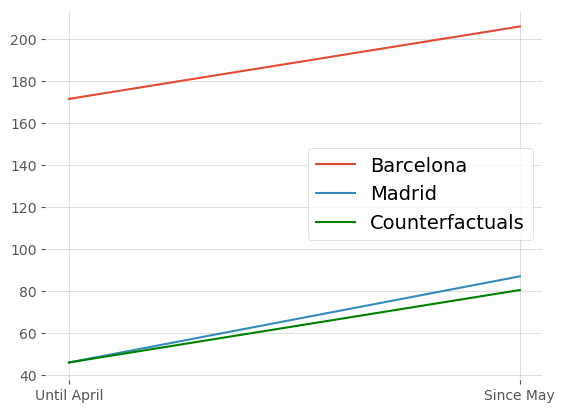

In [85]:
plt\
    .plot(["Until April", "Since May"],
         [barcelona_before, barcelona_after],
         label = "Barcelona")

plt\
    .plot(["Until April", "Since May"],
         [madrid_before, madrid_after],
         label = "Madrid")

# Team, we compare against "Counterfactuals" ["Compared with What?"]

plt\
    .plot(["Until April", "Since May"],
          # let's compute counterfactuals here
          [madrid_before, madrid_before + (barcelona_after - barcelona_before)],
          label = "Counterfactuals",
          color = "green"
         )


plt.legend()

### MODEL (`How to Model DiD?`)

In [86]:
did_data.columns

Index(['deposits', 'madrid', 'May'], dtype='object')

### How to formally estimate Difference-in-Differences (DiD) Estimation (with Interaction Effects)

$$
    Y = \alpha + \beta \text{Strategy} + \gamma \text{BeforeAfter} + \delta(\text{strategy} \times \text{BeforeAfter}) + \epsilon
$$

In [87]:
formal_modeling_of_DiD =\
(
    smf
    .ols(formula = "deposits ~ madrid * May",
         data = did_data)
    .fit()
)

formal_modeling_of_DiD\
    .summary()\
    .tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,171.6423,2.363,72.625,0.000,167.009,176.276
madrid,-125.6263,4.484,-28.015,0.000,-134.418,-116.835
May,34.5232,3.036,11.372,0.000,28.571,40.475
madrid:May,6.5246,5.729,1.139,0.255,-4.706,17.755


### Advantages:

- Controls for unobserved time-invariant confounders.
<br>

- Applicable to panel data settings with treatment and control groups.

### Disadvantages:

- Assumes parallel trends between treatment and control groups in the absence of treatment.
<br>

- Sensitive to the choice of control group and time period.

## <font color = "purple"> ***TO BE CONTINUED :) Yay~*** </font>

## <a id = "p7">7.</a>  <font color = "green"> Regression Discontinuity (RDD) </font>  [back to table of contents](#top)

### Analytics Contexts

> RDD is useful when a treatment, strategy, or policy is assigned based on a threshold value in a continuous variable. It compares the outcomes of observations just above and below the threshold to estimate the causal effect of the treatment.

> Sharp Regression Discontinuity Design (RDD)

- $Y_i$ denotes the outcome of interest for observation \( i\)

- $D_i$ denotes a binary indicator for treatment assignment, equal to 1 if the assignment for observation is above the cutoff, and 0 otherwise.

- $\tau$ is the coefficient of interest, representing the causal effect of the treatment.

### Business Contexts

> RDD can be employed in scenarios like evaluating the impact of a new loan policy on loan repayment rates, where applicants with credit scores above a certain threshold are approved.

> Regression discontinuity is like a science experiment where you want to see if a change makes a difference. Imagine you're playing a game where you get a prize if you score above a certain number. You and your friends want to see if a new toy makes you score better. So, you play the game once with the old toy and then play the game again with the new toy. The difference in your scores before and after playing with the new toy is the "difference" in the experiment.

> Regression discontinuity works similarly, but instead of toys and games, it uses data and statistics to see if a change has an effect. Researchers use regression discontinuity to study the impact of a certain policy or treatment by comparing two groups of people who are similar in many ways, but differ in one key aspect: whether they are eligible or not eligible for the policy or treatment based on a specific cutoff point.

### IMPORT

In [88]:
# alcohol =\
# (
#     pd
#     .read_csv("https://talktoroh.squarespace.com/s/alcohol.csv")
# )

#### `mva` denotes: `m`oving `v`ehicle `a`ccident 

### WRANGLE

### VISUALIZE

### MODEL for Regression Discontinuity

> Assumption of RDD


> Regression Specification for RD

> Because of the above model specification for regression discontinuity, we should use `weigthed least squares.`

> Learn How to Learn

### Visualize the Model

### In the field, you should pay attention to data storytelling.

### Pro-tips [`Best Practice`]: In the field, please use `kernel` weighting

> The condition of the kernel weighting:

### Advantages:

* Causal estimates are less sensitive to unobserved confounders.
<br>

* Suitable for non-experimental settings with clear threshold rules.

### Disadvantages:

* Limited to cases with clear thresholds.
<br>

* Results may not be generalizable beyond the threshold.
<br>

* Sensitive to bandwidth choice and functional form assumptions.

### Ultimate Reports of RDD: Team, make sure to `adjust your causal effects with kernel weights`

## <a id = "p8">8.</a>  <font color = "green"> What We Learned & What's Next </font>  [back to table of contents](#top)

    PERSONAL NOTE:

- 
- 

> `Thank you for working with the script, Team 👍`